[2026-03-03 11:02:49] === 3銘柄をランダムに選択 ===
選ばれた3銘柄:
 - USDC
 - SOL
 - AVAX
[2026-03-03 11:02:49] Fetching USDC ...
[2026-03-03 11:02:52] Fetching SOL ...
[2026-03-03 11:02:53] Fetching AVAX ...


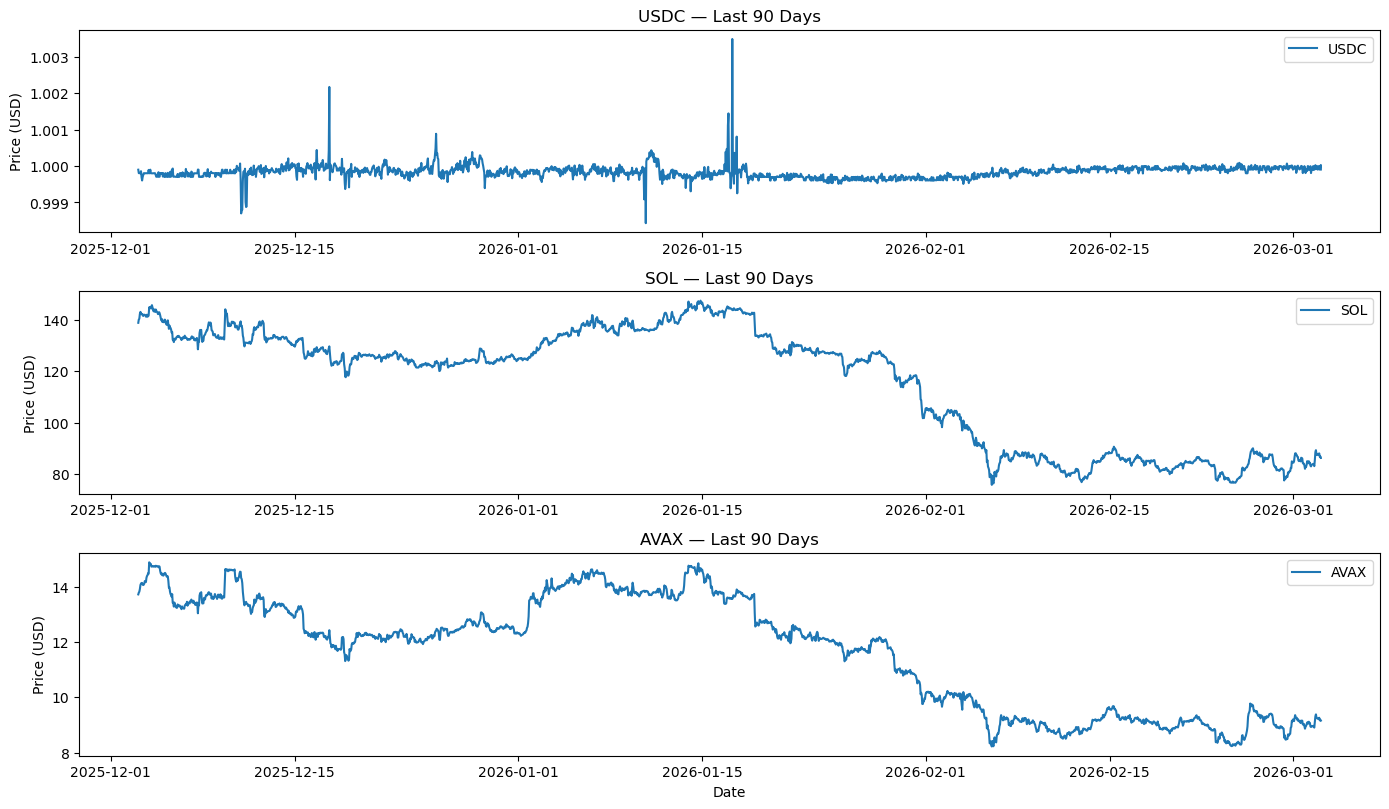

[2026-03-03 11:02:56] === 価格系列の変化点検知（表を作成） ===
[2026-03-03 11:02:56] Detecting changepoints for USDC ...
[2026-03-03 11:02:56] [USDC] changepoint detection start (n=2162)


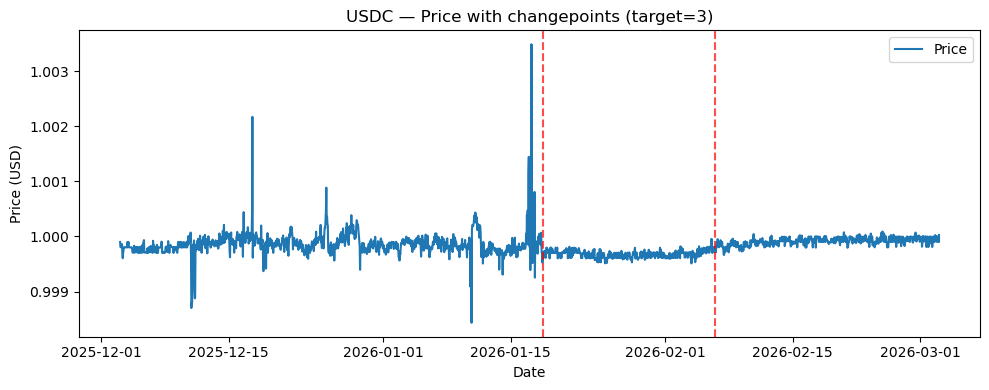

[2026-03-03 11:11:26] [USDC] detected changepoints (indices): [1115, 1570]
[2026-03-03 11:11:26] Detecting changepoints for SOL ...
[2026-03-03 11:11:26] [SOL] changepoint detection start (n=2162)


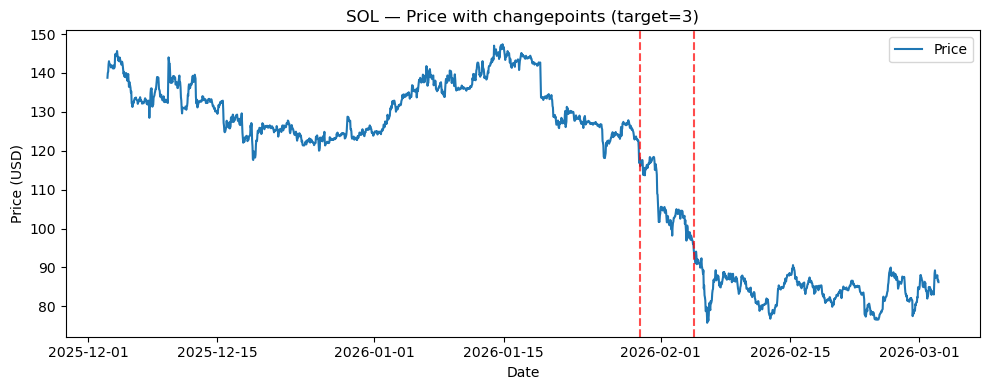

[2026-03-03 11:20:01] [SOL] detected changepoints (indices): [1385, 1525]
[2026-03-03 11:20:02] Detecting changepoints for AVAX ...
[2026-03-03 11:20:02] [AVAX] changepoint detection start (n=2161)


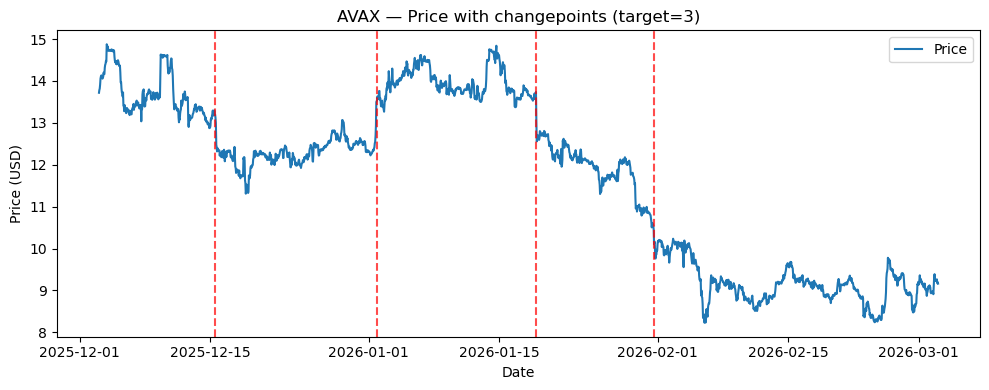

[2026-03-03 11:26:23] [AVAX] detected changepoints (indices): [300, 715, 1125, 1430]

=== 3銘柄の変化点一覧 ===
symbol  cp_no  cp_index            cp_timestamp   cp_price
  USDC      1      1115 2026-01-18 13:01:23.044   0.999708
  USDC      2      1570 2026-02-06 12:03:01.208   0.999796
   SOL      1      1385 2026-01-29 19:02:18.559 116.022442
   SOL      2      1525 2026-02-04 15:01:43.841  93.560353
  AVAX      1       300 2025-12-15 14:00:41.214  13.123582
  AVAX      2       715 2026-01-01 21:02:24.882  13.522887
  AVAX      3      1125 2026-01-18 23:00:52.753  13.737271
  AVAX      4      1430 2026-01-31 16:02:00.447  10.169062


In [8]:
import random
import time
from datetime import datetime

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
import ruptures as rpt


# ------------------------
# 設定
# ------------------------
COINS_POOL = [
    ("bitcoin", "BTC"),
    ("ethereum", "ETH"),
    ("tether", "USDT"),
    ("binancecoin", "BNB"),
    ("solana", "SOL"),
    ("ripple", "XRP"),
    ("usd-coin", "USDC"),
    ("cardano", "ADA"),
    ("dogecoin", "DOGE"),
    ("avalanche-2", "AVAX"),
]

VS = "usd"
DAYS = 90
BASE = "https://api.coingecko.com/api/v3/coins/{id}/market_chart"

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})


def log(msg: str):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}")


# ------------------------
# データ取得
# ------------------------
def fetch_market_chart(coin_id, days=90, vs="usd"):
    """
    CoinGecko から指定銘柄の market_chart データを取得して
    timestamp, price の DataFrame を返す。
    """
    url = BASE.format(id=coin_id)
    params = {"vs_currency": vs, "days": days}

    r = session.get(url, params=params, timeout=30)
    r.raise_for_status()

    data = r.json()
    df = pd.DataFrame(data["prices"], columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.sort_values("timestamp")
    return df


# ------------------------
# 変化点検知（ログ価格, ruptures / PELT）
# ------------------------
def detect_and_plot_changepoints(df: pd.DataFrame, symbol: str, n_bkps: int = 3):
    """
    価格系列（ログ価格）に対して変化点検知を行い、
    pen を調整して変化点数を n_bkps 付近にする。
    さらに、変化点の情報を「行のリスト」として返す。
    """
    # 分析用系列：対数価格
    series = np.log(df["price"].values.astype(float)).reshape(-1, 1)

    log(f"[{symbol}] changepoint detection start (n={len(series)})")

    algo = rpt.Pelt(model="rbf").fit(series)

    # 初期ペナルティ（系列長に応じて適当に）
    pen = np.log(len(series)) if len(series) > 1 else 1.0

    # pen を調整して変化点数を n_bkps に近づける
    for _ in range(20):  # 最大20回トライ
        bkps = algo.predict(pen=pen)
        num = len(bkps) - 1  # 最後は len(series) なので -1 が「変化点数」

        if num > n_bkps:
            pen *= 1.5  # 多すぎ → ペナルティ強く
        elif num < n_bkps:
            pen /= 1.5  # 少なすぎ → ペナルティ弱く
        else:
            break

    # 最終結果
    bkps = algo.predict(pen=pen)

    # 表用のデータを作る
    rows = []
    for i, b in enumerate(bkps[:-1], start=1):   # 最後の len(series) は終端なので除外
        if 0 < b < len(df):
            ts = df["timestamp"].iloc[b]
            price_at_cp = df["price"].iloc[b]
            rows.append({
                "symbol": symbol,             # 銘柄
                "cp_no": i,                   # その銘柄の何番目の変化点か
                "cp_index": int(b),           # 時系列インデックス
                "cp_timestamp": ts,           # 変化点時刻
                "cp_price": float(price_at_cp),  # 変化点時の価格
            })

    # プロット
    plt.figure(figsize=(10, 4))
    plt.plot(df["timestamp"], df["price"], label="Price")

    for r in rows:
        plt.axvline(r["cp_timestamp"], color="red", linestyle="--", alpha=0.7)

    plt.title(f"{symbol} — Price with changepoints (target={n_bkps})")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.xlabel("Date")
    plt.legend()
    plt.tight_layout()
    plt.show()

    log(f"[{symbol}] detected changepoints (indices): {[r['cp_index'] for r in rows]}")
    return rows


# ------------------------
# 価格そのものに AR を当てて in-sample 1ステップ先予測を見る
# ------------------------
def apply_ar_price_in_sample(df: pd.DataFrame, symbol: str, lags: int = 5):
    """
    価格そのものに AR(lags) をフィットして、
    ・in-sample の 1 ステップ先予測 (fitted values) を取得
    ・末尾区間で、実データと重ねてプロットする
    """
    series = pd.Series(df["price"].values.astype(float))
    n = len(series)

    if n <= lags + 5:
        log(f"[{symbol}] series too short for AR({lags}), skip")
        return None, None

    log(f"[{symbol}] Fitting AR({lags}) on price (length={n})")
    model = AutoReg(series, lags=lags, old_names=False)
    res = model.fit()

    # fittedvalues: index = lags .. n-1
    fitted = res.fittedvalues
    actual = series[lags:]
    N = len(series)

    idx = np.arange(lags, N)  # lags .. N-1

    # 末尾 tail 点だけ表示（最大50点）
    tail = min(50, len(idx))
    idx_tail = idx[-tail:]
    actual_tail = actual.iloc[-tail:]
    fitted_tail = fitted.iloc[-tail:]

    # 念のため長さを揃える
    min_len = min(len(idx_tail), len(actual_tail), len(fitted_tail))
    idx_tail = idx_tail[-min_len:]
    actual_tail = actual_tail.iloc[-min_len:]
    fitted_tail = fitted_tail.iloc[-min_len:]

    mse = ((actual_tail.values - fitted_tail.values) ** 2).mean()
    rmse = np.sqrt(mse)
    log(f"[{symbol}] AR({lags}) in-sample (last {min_len} pts) MSE={mse:.6e}, RMSE={rmse:.6e}")

    # プロット
    plt.figure(figsize=(10, 4))
    plt.plot(idx_tail, actual_tail.values, label="Actual price")
    plt.plot(idx_tail, fitted_tail.values, "--", label="AR fitted price")
    plt.title(f"AR({lags}) on price (in-sample) - {symbol}")
    plt.xlabel("Time index")
    plt.ylabel(f"Price ({VS.upper()})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return mse, rmse


# ------------------------
# メイン処理：3選択 → 価格プロット → 変化点 → 表 → AR
# ------------------------
def main():
    log("=== 3銘柄をランダムに選択 ===")

    # 3つランダムに選択
    selected = random.sample(COINS_POOL, 3)
    print("選ばれた3銘柄:")
    for _, sym in selected:
        print(" -", sym)

    dfs = {}

    # ---------- まず素の価格を3段プロット ----------
    plt.figure(figsize=(14, 8))

    for idx, (coin_id, symbol) in enumerate(selected, start=1):
        log(f"Fetching {symbol} ...")
        df = fetch_market_chart(coin_id, DAYS, VS)
        dfs[symbol] = df

        plt.subplot(3, 1, idx)
        plt.plot(df["timestamp"], df["price"], label=symbol)
        plt.title(f"{symbol} — Last {DAYS} Days")
        plt.ylabel(f"Price ({VS.upper()})")
        plt.legend()
        plt.tight_layout()

        time.sleep(0.5)

    plt.xlabel("Date")
    plt.show()

    # ---------- 変化点検知（表用データを集約） ----------
    log("=== 価格系列の変化点検知（表を作成） ===")
    all_rows = []

    for symbol, df in dfs.items():
        log(f"Detecting changepoints for {symbol} ...")
        rows = detect_and_plot_changepoints(df, symbol, n_bkps=3)
        all_rows.extend(rows)
        time.sleep(0.5)

    # pandas の表にまとめる
    if all_rows:
        cp_table = pd.DataFrame(all_rows)
        print("\n=== 3銘柄の変化点一覧 ===")
        print(cp_table.to_string(index=False))
    else:
        print("\n変化点が検出されませんでした。")

    # ---------- 価格に AR(=in-sample 1step) を適用（おまけ） ----------
    #log("=== 価格そのものに AR を適用（in-sample 予測） ===")
    #for symbol, df in dfs.items():
    #    log(f"Applying AR on PRICE for {symbol} ...")
    #    apply_ar_price_in_sample(df, symbol, lags=5)
    #    time.sleep(0.5)


if __name__ == "__main__":
    main()